In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [5]:
# Things we may want to report for the checkpoint 1 about our dataset:
# - Summarize relevant dataset properties (num. instances, num. features, etc.)
# - Define each observation (is it vector or scalar? is it any real or is it constrained to be positive?)
# - Briefly explain if any preprocessing is necessary (missing values? standardization?)

## Load the Dataset

In [6]:
data_flag = 'dermamnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [70]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [71]:
print(train_dataset)
print("===================")
print(val_dataset)
print("===================")
print(test_dataset)

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /Users/michaelbehrens/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Dataset DermaMNIST of size 28 (dermamnist)
    Number of

In [72]:
short_labels = {
    0: 'AKIEC',
    1: 'BCC',
    2: 'BKL',
    3: 'DF',
    4: 'MEL',
    5: 'MN',
    6: 'VASC'
}
long_labels = {int(k): v for k, v in info['label'].items()}
label_lookup = {v: info['label'][str(k)] for k, v in short_labels.items()}

In [73]:
label_lookup

{'AKIEC': 'actinic keratoses and intraepithelial carcinoma',
 'BCC': 'basal cell carcinoma',
 'BKL': 'benign keratosis-like lesions',
 'DF': 'dermatofibroma',
 'MEL': 'melanoma',
 'MN': 'melanocytic nevi',
 'VASC': 'vascular lesions'}

## Summarizing Dataset Properties

In [74]:
# How many instances / examples do we have?
print(f'Number of training examples: {len(train_dataset)}')
print(f'Number of validation examples: {len(val_dataset)}')
print(f'Number of test examples: {len(test_dataset)}')

Number of training examples: 7007
Number of validation examples: 1003
Number of test examples: 2005


In [75]:
def plot_class_distribution():
    datasets = [train_dataset, val_dataset, test_dataset]
    titles = ['Training Class Distribution', 'Validation Class Distribution', 'Test Class Distribution']

    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    for ax, dataset, title in zip(ax, datasets, titles):
        labels = np.array(dataset.labels)

        # Create a histogram of training class distribution
        ax.hist(labels, bins=np.arange(n_classes + 1) - 0.5, density=False)
        ax.set_title(title)
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        # add text of the labels themselves below the axis at an angle
        ax.set_xticks(ticks=np.arange(n_classes))
        ax.set_xticklabels([short_labels[i] for i in range(n_classes)], rotation=45)
        # add count of each class above the bars
        for i in range(n_classes):
            count = np.sum(labels == i)
            ax.text(i, count + 5, str(count), ha='center')

    plt.tight_layout()
    plt.show()

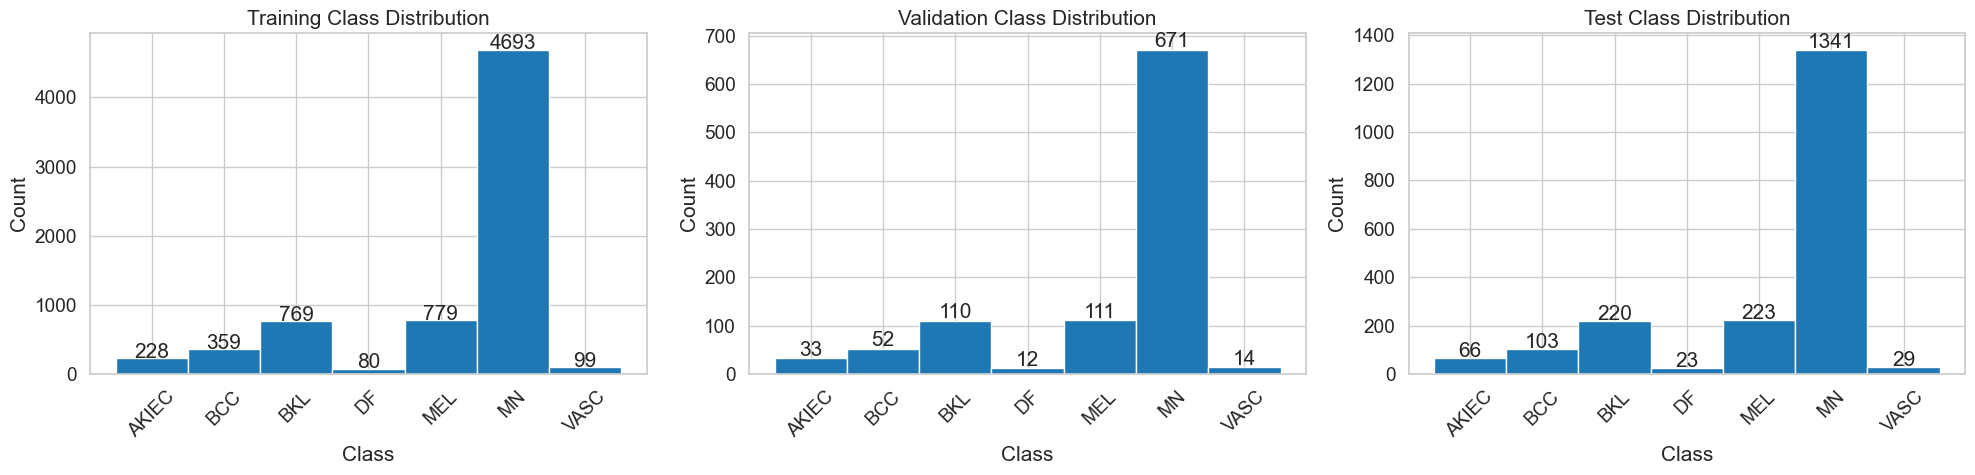

In [76]:
# What is the class distribution?
plot_class_distribution()


## Defining Dataset Observations

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27058822..0.78039217].


Sample image shape: torch.Size([3, 28, 28])
Sample label shape: (1,)
Image values from -0.270588219165802 to 0.7803921699523926


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

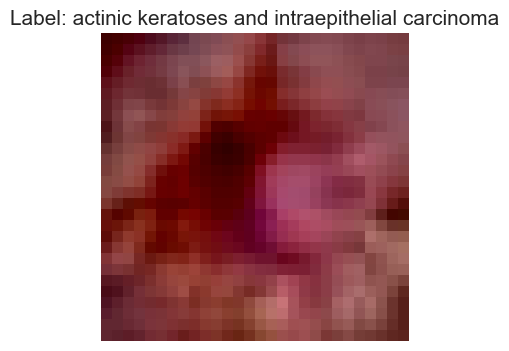

In [77]:
# What is the type and shape of inputs and outputs?

# Load one sample image from the train set
sample_image, sample_label = train_dataset[0]
print(f'Sample image shape: {sample_image.shape}')
print(f'Sample label shape: {sample_label.shape}')
print(f'Image values from {sample_image.min()} to {sample_image.max()}')

# Show the sample image and print its sample label name
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.permute(1, 2, 0), cmap='gray')
plt.title(f'Label: {long_labels[sample_label[0]]}')
plt.axis('off')

## Data Preprocessing

In [78]:
# The MNIST dataset is already loaded as 3x28x28 tensors, and the values are all normalized between -1 and 1, with mean 0.5 and std dev 0.5

# Next, we need to figure out:
# a) What percentage of data do we strip labels for?
# b) What is the process of doing that? I assume we keep the same proportion of labeled/unlabeled across classes.

In [95]:
def get_semi_supervised_labels(dataset, unlabeled_rate, seed=42, n_classes=7):
    labels = np.array(dataset.labels).flatten().astype(np.int16)
    semi_supervised_labels = labels.copy()
    np.random.seed(seed)
    for c in range(n_classes):
        # find the indices of the full examples that belong to class c
        class_indices = np.where(labels == c)[0]
        # next, randomly choose a subset of those indices to be unlabeled, according to the specified unlabeled rate
        num_unlabeled = int(len(class_indices) * unlabeled_rate)
        unlabeled_indices = np.random.choice(class_indices, size=num_unlabeled, replace=False)
        # set the labels of those indices to -1
        semi_supervised_labels[unlabeled_indices] = -1
    return semi_supervised_labels

In [100]:
labels = np.array(train_dataset.labels).flatten().astype(np.int16)
class_counts_labeled = {}
for c in range(n_classes):
    class_indices = np.where(labels == c)[0]
    class_counts_labeled[c] = len(class_indices)
print(f'Before unlabeling procedure:\n {class_counts_labeled}')
print(f'Total number of labeled examples: {len(labels)}')

print("=========")

unlabeled_rate = 0.5
semi_supervised_labels = get_semi_supervised_labels(train_dataset, unlabeled_rate)
class_counts_semi_supervised = {}
total_labeled = 0
for c in range(n_classes):
    class_indices = np.where(semi_supervised_labels == c)[0]
    class_counts_semi_supervised[c] = len(class_indices)
    total_labeled += len(class_indices)
class_counts_semi_supervised[-1] = len(np.where(semi_supervised_labels == -1)[0])
print(f'After unlabeling procedure with rate {unlabeled_rate}:\n {class_counts_semi_supervised}')
print(f'Total number of labeled examples: {total_labeled}')
print(f'Total number of unlabeled examples: {class_counts_semi_supervised[-1]}')

Before unlabeling procedure:
 {0: 228, 1: 359, 2: 769, 3: 80, 4: 779, 5: 4693, 6: 99}
Total number of labeled examples: 7007
After unlabeling procedure with rate 0.5:
 {0: 114, 1: 180, 2: 385, 3: 40, 4: 390, 5: 2347, 6: 50, -1: 3501}
Total number of labeled examples: 3506
Total number of unlabeled examples: 3501


In [ ]:
# TODO: we should figure out what a reasonable unlabeled rate is. We can also try a few different rates and see how performance changes